# normal pipeline (no normalization)

In [1]:
import importlib
import sys
from pathlib import Path

# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

In [ ]:
# ========== TRANSECT 057 (DEFAULT) ==========
# Load transect 057
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file from transect 057
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...


In [ ]:
cube.apply_illumination_correction_v2()

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk


array([[[2.2304249e+00, 1.6764377e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.0077596e+00, 0.0000000e+00],
        [7.4757171e+00, 8.5974735e-01, 0.0000000e+00, ...,
         0.0000000e+00, 3.0958059e+00, 0.0000000e+00],
        [1.8294926e+00, 2.3438740e+00, 0.0000000e+00, ...,
         0.0000000e+00, 7.1090145e+00, 0.0000000e+00],
        ...,
        [1.7213115e+00, 1.4317783e+00, 0.0000000e+00, ...,
         1.0000000e+00, 2.3279436e-02, 3.7040919e-01],
        [5.8812752e+00, 2.0123754e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.4956644e+00, 0.0000000e+00],
        [2.3867478e+00, 1.0000000e+00, 0.0000000e+00, ...,
         0.0000000e+00, 1.5736811e+01, 4.5105180e-01]],

       [[2.2304249e+00, 7.7452070e-01, 3.9940205e+00, ...,
         0.0000000e+00, 0.0000000e+00, 9.6023534e-05],
        [1.7471981e+00, 0.0000000e+00, 1.2654871e+00, ...,
         0.0000000e+00, 8.5029960e-01, 6.3767982e-01],
        [1.9216584e+00, 0.0000000e+00, 3.0771544e+00, ...,
         0.000

In [ ]:
# Import ROIs
cube.import_rois("./rois/057_5_combined.json")
cube.list_rois()

📂 Imported 6 ROIs from ./rois/057_5_combined.json

📂 ROI Collection (6 ROIs):
 1. 'validation_dark': 358 pixels
     Slit range:  174 - 740
     Track range: 729 - 1416
 2. 'validation_bombs': 454 pixels
     Slit range:  244 - 880
     Track range: 593 - 1547
 3. 'validation_sediment': 273 pixels
     Slit range:   14 - 870
     Track range: 577 - 1580
 4. 'training_dark': 364 pixels
     Slit range:   24 - 962
     Track range:  23 - 2420
 5. 'training_sediment': 398 pixels
     Slit range:   31 - 924
     Track range:  51 - 2417
 6. 'training_bombs': 201 pixels
     Slit range:  513 - 794
     Track range: 2136 - 2416


In [ ]:
# Apply smoothing BEFORE wavelength filter (force recompute to avoid cache issues)
cube.apply_spectral_smoothing(
    method="gaussian",
    gaussian_sigma=5.0,
)

💾 Found cached smoothing (gaussian, corrected data) - loading from disk (much faster!)
📂 Loading saved spectral smoothing (gaussian, corrected data) from 1 files...
   rad_uhi_20241029_115057_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)


array([[[  1.4053802 ,   1.2650696 ,   1.1382263 , ...,   1.1283655 ,
           0.97737503,   0.83948207],
        [  4.6651793 ,   4.2503104 ,   3.8811233 , ...,   1.1326705 ,
           0.9723464 ,   0.8175835 ],
        [  1.3719033 ,   1.2897086 ,   1.2119116 , ...,   1.8223882 ,
           1.5475298 ,   1.2971877 ],
        ...,
        [  1.3580438 ,   1.3156981 ,   1.2867721 , ...,   0.56639993,
           0.4903108 ,   0.43773448],
        [  3.5521085 ,   3.1614618 ,   2.791659  , ...,   1.3441232 ,
           1.1704057 ,   0.9949217 ],
        [  1.6943413 ,   1.6141984 ,   1.5584607 , ...,   2.2617679 ,
           2.1754954 ,   2.0517063 ]],

       [[  2.318576  ,   2.3062904 ,   2.2812638 , ...,   1.101198  ,
           0.9108031 ,   0.7313268 ],
        [  2.301428  ,   2.3859735 ,   2.4506774 , ...,   1.2345957 ,
           1.1081169 ,   0.99427783],
        [  2.7406316 ,   3.0454702 ,   3.413178  , ...,   1.9089841 ,
           1.5757452 ,   1.2690792 ],
        ...,


In [ ]:
# Define ROI collections
training_rois = [
    "training_dark",
    "training_sediment",
    "training_bombs",
]

validation_rois = [
    "validation_dark",
    "validation_sediment",
    "validation_bombs",
]

print(f"Training ROIs: {training_rois}")
print(f"Validation ROIs: {validation_rois}")

Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']
Validation ROIs: ['validation_dark', 'validation_sediment', 'validation_bombs']


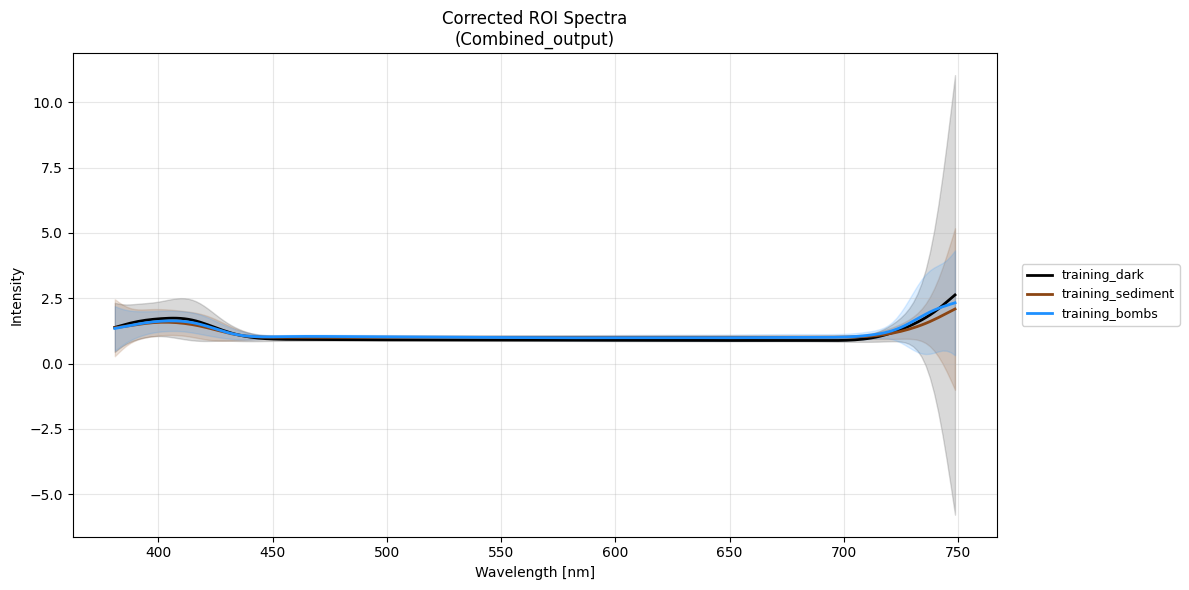

In [ ]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


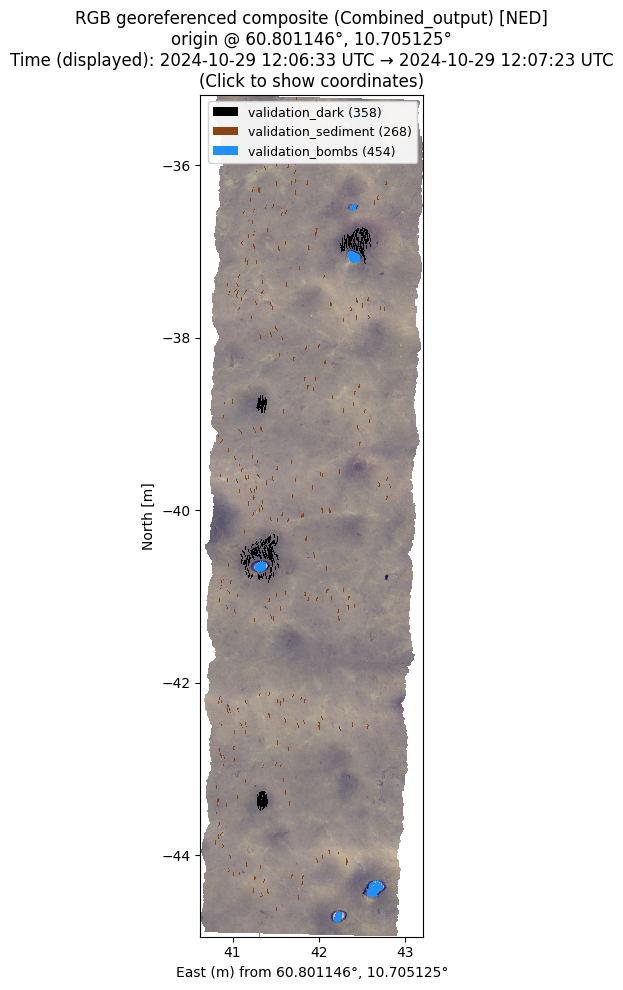

In [ ]:
# Plot validation ROIs with SOLID OVERLAY
%matplotlib inline

cube.plot_georef(
    apply_alignment_shift=True,
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(30, 10),
    roi_collection=validation_rois,
    roi_solid_pixel_size=5,

    roi_overlay_mode="solid",  # NEW: Use solid pixel overlay instead of markers
)


In [ ]:
# Crop wavelengths to 490-700 nm (UPDATED)
cube.apply_wavelength_filter(wavelength_range=(490, 700))

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB


array([[[1.0242817 , 1.0233774 , 1.0235972 , ..., 1.0452163 ,
         1.0459423 , 1.047293  ],
        [1.0548365 , 1.0539597 , 1.0523418 , ..., 1.0706059 ,
         1.0636694 , 1.0545129 ],
        [1.0433822 , 1.0478745 , 1.0514694 , ..., 1.0309559 ,
         1.0289329 , 1.0286332 ],
        ...,
        [1.0650878 , 1.0582087 , 1.0508734 , ..., 1.0319183 ,
         1.0231724 , 1.0166652 ],
        [1.0264505 , 1.0296129 , 1.03321   , ..., 1.0880054 ,
         1.0686986 , 1.0491787 ],
        [1.0137969 , 1.0122609 , 1.0117648 , ..., 1.0593293 ,
         1.0531667 , 1.0422413 ]],

       [[1.0191454 , 1.0156488 , 1.0118141 , ..., 1.091157  ,
         1.0910306 , 1.0903581 ],
        [1.0168545 , 1.0150243 , 1.0127909 , ..., 1.0194405 ,
         1.0147187 , 1.0108873 ],
        [1.059358  , 1.0585549 , 1.057203  , ..., 1.0557945 ,
         1.0621332 , 1.0710251 ],
        ...,
        [1.0225906 , 1.0255002 , 1.0263999 , ..., 1.1815886 ,
         1.2010847 , 1.2249782 ],
        [1.0

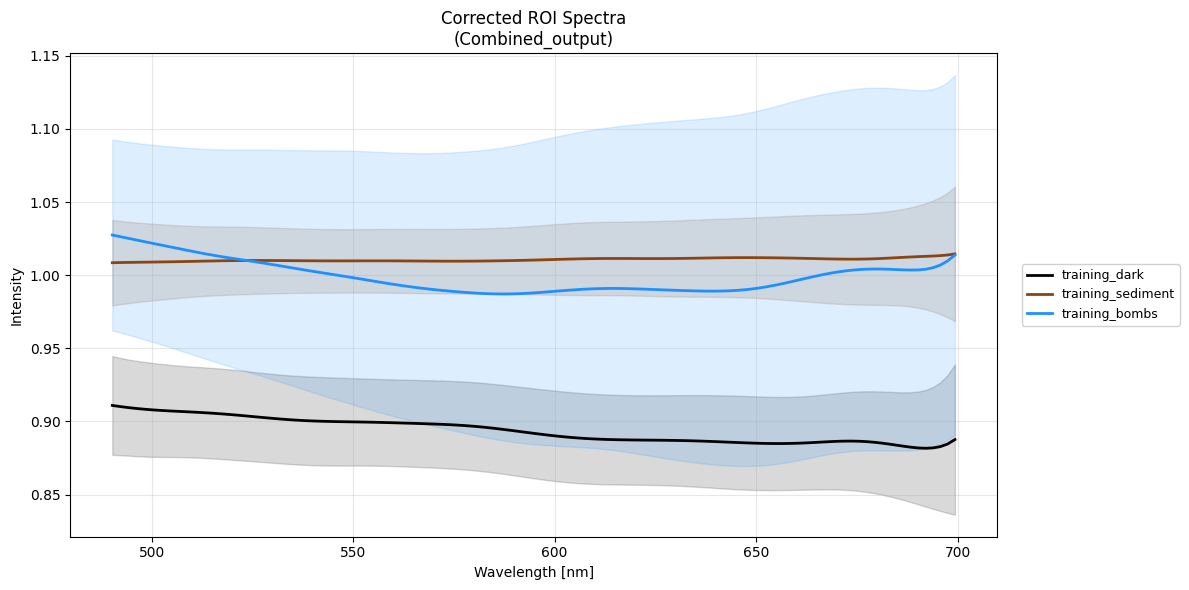

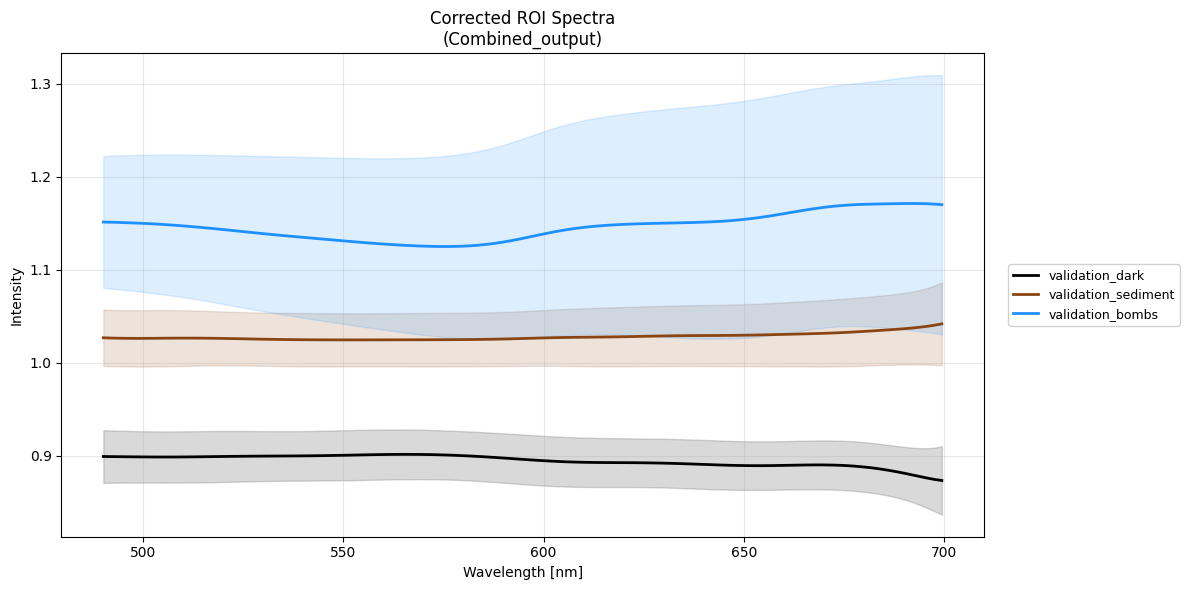

In [ ]:
# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=training_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

# Plot preprocessed spectra (no additional processing - already done)
cube.plot_spectrum(
    roi_names=validation_rois,
    use_corrected=True,
    wavelength_range=None,  # Already cropped in memory
    # wavelength_smoothing=1,  # Already smoothed in memory
    interpolate_wavelengths=None,  # Already interpolated in memory
    normalize_method=None,  # Already normalized in memory
    legend_loc="outside",
    use_inline_labels=False,
    show_std=True,
)

In [ ]:
# Train SVM with spatial cross-validation
cv_results = cube.train_svm_with_cv(
    training_rois=training_rois,
    segment_start=config.UHI_TRACK_RANGE[0],
    segment_end=config.UHI_TRACK_RANGE[1],
    cv_folds=5,
    use_corrected=True,
    svm_kernel="rbf",
    optimize_params=True,
    add_brightness_feature=False,
    quiet=False,
    use_intensity_only=True,
)

# Print summary
print(f"\n" + "=" * 60)
print(f"📊 CROSS-VALIDATION SUMMARY")
print(f"=" * 60)
print(
    f"Accuracy:  {cv_results['cv_mean_metrics']['accuracy_mean']:.3f} ± {cv_results['cv_mean_metrics']['accuracy_std']:.3f}"
)
print(
    f"Precision: {cv_results['cv_mean_metrics']['precision_mean']:.3f} ± {cv_results['cv_mean_metrics']['precision_std']:.3f}"
)
print(
    f"Recall:    {cv_results['cv_mean_metrics']['recall_mean']:.3f} ± {cv_results['cv_mean_metrics']['recall_std']:.3f}"
)
print(
    f"F1 Score:  {cv_results['cv_mean_metrics']['f1_mean']:.3f} ± {cv_results['cv_mean_metrics']['f1_std']:.3f}"
)

print(f"\n🎯 Best hyperparameters:")
print(f"  C = {cv_results['best_params']['C']}")
print(f"  gamma = {cv_results['best_params']['gamma']}")

print(f"\n📍 Training pixels used:")
for class_name, count in cv_results["training_pixels_per_class"].items():
    print(f"  {class_name}: {count} pixels")

🤖 SVM TRAINING WITH CROSS-VALIDATION
💡 MODE: Intensity-only classification (mean intensity as single feature)

�📦 Datacube shape: (2462, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1566
📍 Training ROIs: ['training_dark', 'training_sediment', 'training_bombs']

🔍 Filtering ROI pixels...
   training_dark: 364 pixels (rejected 0 inside segment)
   training_sediment: 397 pixels (rejected 1 inside segment)
   training_bombs: 201 pixels (rejected 0 inside segment)

💡 Intensity-only mode activated:
   Intensity range: [0.7589, 1.1574]
   Intensity mean: 0.9641 ± 0.0750
   Feature dimensionality: 1 (mean intensity only)

✅ Training data: 962 pixels, 1 features
   Features: 1 mean intensity value
   Kept (outside segment): 962
   Rejected (inside segment): 1

🔬 Creating spatial groups for CV...
   Settings: closing_radius=3, min_group_size=20
   Sediment grid: 100(slit) × 200(track) px, min=10
   training_dark: 364 pixels → 6 groups via connected_components
      dark#A: 11

KeyboardInterrupt: 

In [ ]:
# Compute additional CV metrics
from sklearn.metrics import cohen_kappa_score

print(f"\n" + "=" * 60)
print(f"📊 ADDITIONAL CV METRICS")
print(f"=" * 60)

# Macro F1 (average F1 across all classes)
macro_f1_mean = cv_results["cv_mean_metrics"]["f1_mean"]
macro_f1_std = cv_results["cv_mean_metrics"]["f1_std"]

print(f"Macro F1:  {macro_f1_mean:.3f} ± {macro_f1_std:.3f}")

# Kappa is computed per-fold during CV, let's extract if available
# Note: If not available in cv_results, we can compute from validation later
if "kappa_mean" in cv_results["cv_mean_metrics"]:
    kappa_mean = cv_results["cv_mean_metrics"]["kappa_mean"]
    kappa_std = cv_results["cv_mean_metrics"]["kappa_std"]
    print(f"Cohen's Kappa (κ): {kappa_mean:.3f} ± {kappa_std:.3f}")

    # Interpretation
    if kappa_mean > 0.8:
        interpretation = "Strong agreement"
    elif kappa_mean > 0.6:
        interpretation = "Substantial agreement"
    elif kappa_mean > 0.4:
        interpretation = "Moderate agreement"
    elif kappa_mean > 0.2:
        interpretation = "Fair agreement"
    else:
        interpretation = "Slight agreement"
    print(f"   Interpretation: {interpretation}")
else:
    print("⚠️  Kappa not computed during CV (will compute from validation)")

print("=" * 60)

In [ ]:
# Visualize filtered training ROIs
cube.plot_georef(
    use_corrected=True,
    figsize=(40, 10),
    roi_collection=cv_results["filtered_training_rois"],
    roi_marker_edgewidth=0,
    roi_solid_pixel_size=11,
    roi_overlay_mode="solid",
)

In [ ]:
# Plot spatial groups created during training
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    cube.plot_georef(
        use_corrected=True,
        figsize=(40, 10),
        roi_collection=cv_results["spatial_groups_roi_collection"],
        roi_marker_size=3,
        roi_legend_loc="outside",
        roi_marker_edgewidth=0,
        roi_legend_markersize=40,
        roi_solid_pixel_size=11,
        roi_overlay_mode="solid",
    )

    # Print group info
    print("\n📊 Spatial Groups Created:")
    for group_name, pixels in sorted(
        cv_results["spatial_groups_roi_collection"].items()
    ):
        print(f"   {group_name}: {len(pixels)} pixels")
else:
    print(
        "⚠️ No spatial groups found in cv_results. Training may not have used spatial clustering."
    )

In [ ]:
# Plot spectra for all spatial groups
if (
    "spatial_groups_roi_collection" in cv_results
    and cv_results["spatial_groups_roi_collection"]
):
    # Temporarily add spatial groups to ROI collection
    original_rois = cube.roi_collection.copy()
    cube.roi_collection.update(cv_results["spatial_groups_roi_collection"])

    # Plot spectra
    cube.plot_spectrum(
        roi_names=list(cv_results["spatial_groups_roi_collection"].keys()),
        use_corrected=True,
        wavelength_range=(490, 680),
        wavelength_smoothing=10,
        interpolate_wavelengths=[64, 107, 138],
        normalize_method=None,
        legend_loc="outside",
        use_inline_labels=False,
        show_std=False,
    )

    # Restore original ROI collection
    cube.roi_collection = original_rois
else:
    print("⚠️ No spatial groups found in cv_results.")

In [ ]:
# Classify segment - outputs classified_bombs, classified_dark, classified_sediment
print("🎯 STEP 1: CLASSIFICATION")
print("=" * 60)

classification_results = cube.classify_segment(
    segment_start=config.UHI_TRACK_RANGE[0],
    segment_end=config.UHI_TRACK_RANGE[1],
    use_corrected=True,
    quiet=False,
    confidence_threshold=0,  # ✅ NEW: Reject low-confidence pixels
)

print(f"\n✅ Classification complete!")
print(f"   Classes: {classification_results['class_names']}")
print(f"\n📊 Pixel counts:")
for class_name in classification_results["class_names"]:
    count = np.sum(classification_results["classification_map"] == class_name)
    print(f"   {class_name}: {count} pixels")

In [ ]:
# Plot classification (3 classes)
print("📊 Plotting classification map (3 classes)...")

classification_rois = {}
for class_name in classification_results["class_names"]:
    mask = classification_results["classification_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        classification_rois[class_name] = pixels

print(f"ROIs created: {list(classification_rois.keys())}")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(40, 10),
    roi_collection=classification_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_solid_pixel_size=1,
    roi_overlay_mode="solid",
)

In [ ]:
# Apply filtering - creates filtered_bombs and filtered_dark
print("\n🧹 STEP 2: FILTERING")
print("=" * 60)

filtering_results = cube.filter_classification(
    classification_map=classification_results["classification_map"],
    class_names=classification_results["class_names"],
    filter_bombs=True,
    filter_dark=True,
    filter_sediment=False,
    min_area_px=10,
    connectivity=8,
    morph_close_radius=0,  # Disabled
    morph_open_radius=0,  # Disabled
    merge_proximity_px=0,
    quiet=False,
)

print(f"\n✅ Filtering complete!")
print(f"   All classes after filtering: {filtering_results['all_classes']}")

In [ ]:
# Plot filtered map (5 classes!)
print("📊 Plotting filtered map (5 classes: classified_* + filtered_*)...")

filtered_rois = {}
for class_name in filtering_results["all_classes"]:
    mask = filtering_results["filtered_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        filtered_rois[class_name] = pixels

print(f"ROIs created: {list(filtered_rois.keys())}")
print(f"\n📊 Pixel counts:")
for class_name in sorted(filtered_rois.keys()):
    print(f"   {class_name}: {len(filtered_rois[class_name])} pixels")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(40, 10),
    roi_collection=filtered_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_solid_pixel_size=1,
    roi_overlay_mode="solid",
)

In [ ]:
# Merge filtered classes into new_sediment
print("\n🔀 STEP 3: MERGE FILTERED CLASSES")
print("=" * 60)

merge_results = cube.merge_filtered_to_sediment(
    filtered_map=filtering_results["filtered_map"],
    quiet=False,
)

print(f"\n✅ Merge complete!")
print(f"   Final classes for validation: {merge_results['class_names']}")

In [ ]:
# Plot validation map (3 classes)
print("📊 Plotting validation map (3 classes)...")

validation_map_rois = {}
for class_name in merge_results["class_names"]:
    mask = merge_results["validation_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + config.UHI_TRACK_RANGE[0]) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        validation_map_rois[class_name] = pixels

print(f"ROIs created: {list(validation_map_rois.keys())}")
print(f"\n📊 Pixel counts:")
for class_name in sorted(validation_map_rois.keys()):
    print(f"   {class_name}: {len(validation_map_rois[class_name])} pixels")

cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=config.UHI_TRACK_RANGE[0],
    track_end=config.UHI_TRACK_RANGE[1],
    figsize=(40, 10),
    roi_collection=validation_map_rois,
    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_marker_edgewidth=0,
    roi_legend_markersize=50,
    roi_solid_pixel_size=1,
    roi_overlay_mode="solid",
)

In [ ]:
# Check what classes are in validation_map
unique_classes = np.unique(merge_results["validation_map"])
print(f"Classes in validation_map: {unique_classes}")
print(f"Expected classes: {merge_results['class_names']}")

# Count pixels per class
for class_name in unique_classes:
    count = np.sum(merge_results["validation_map"] == class_name)
    print(f"   {class_name}: {count} pixels")

In [ ]:
# Validate using the 3-class map
print("\n📊 STEP 4: VALIDATION")
print("=" * 60)

validation_results = cube.validate_classification(
    classification_map=merge_results["validation_map"],
    segment_start=config.UHI_TRACK_RANGE[0],
    segment_end=config.UHI_TRACK_RANGE[1],
    validation_rois=validation_rois,
    validation_class_mapping={
        "validation_sediment": "new_sediment",
        "validation_dark": "classified_dark",
        "validation_bombs": "classified_bombs",
    },
    quiet=False,
)

# Print summary
if validation_results:
    print(f"\n" + "=" * 60)
    print(f"📊 VALIDATION RESULTS")
    print(f"=" * 60)
    print(f"Overall Accuracy: {validation_results['accuracy']:.3f}")

    print(f"\n📋 Per-Class Results:")
    for class_name in merge_results["class_names"]:
        print(f"\n{class_name}:")
        print(
            f"  Precision: {validation_results['precision_per_class'][class_name]:.3f}"
        )
        print(f"  Recall:    {validation_results['recall_per_class'][class_name]:.3f}")
        print(f"  F1 Score:  {validation_results['f1_per_class'][class_name]:.3f}")
        print(
            f"  Support:   {validation_results['support_per_class'][class_name]} pixels"
        )

In [ ]:
# Plot confusion matrix
if validation_results:
    import matplotlib.pyplot as plt

    cm = validation_results["confusion_matrix"]
    class_names = merge_results["class_names"]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot confusion matrix as image
    im = ax.imshow(cm, cmap="Greens", aspect="auto")

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Pixel Count", fontsize=12)

    # Set ticks and labels
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    # Rotate x-axis labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add text annotations
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            text = ax.text(
                j,
                i,
                f"{cm[i, j]}",
                ha="center",
                va="center",
                color="black",
                fontsize=12,
            )

    ax.set_xlabel("Predicted Class", fontsize=12)
    ax.set_ylabel("True Class", fontsize=12)
    ax.set_title(
        "Confusion Matrix - Normalized + Smoothed Spectral SVM",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

    # Print normalized confusion matrix (percentages)
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

    print(f"\n📊 Confusion Matrix (Normalized by True Class - Row %):")
    print(f"{'':20s}", end="")
    for pred_class in class_names:
        print(f"{pred_class:>20s}", end="")
    print()
    print("-" * (20 + 20 * len(class_names)))

    for i, true_class in enumerate(class_names):
        print(f"{true_class:20s}", end="")
        for j in range(len(class_names)):
            print(f"{cm_normalized[i, j]:19.1f}%", end="")
        print()

In [ ]:
# Compute additional validation metrics
from sklearn.metrics import cohen_kappa_score
import numpy as np

if validation_results:
    print(f"\n" + "=" * 60)
    print(f"📊 ADDITIONAL VALIDATION METRICS")
    print(f"=" * 60)

    # Extract y_true and y_pred from validation
    # We need to reconstruct these from the confusion matrix
    cm = validation_results["confusion_matrix"]
    class_names = merge_results["class_names"]

    # Reconstruct y_true and y_pred from confusion matrix
    y_true = []
    y_pred = []
    for i, true_class in enumerate(class_names):
        for j, pred_class in enumerate(class_names):
            count = cm[i, j]
            y_true.extend([i] * count)
            y_pred.extend([j] * count)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # 1. Cohen's Kappa
    kappa = cohen_kappa_score(y_true, y_pred)
    print(f"Cohen's Kappa (κ): {kappa:.3f}")

    # Interpretation
    if kappa > 0.8:
        interpretation = "Strong agreement"
    elif kappa > 0.6:
        interpretation = "Substantial agreement"
    elif kappa > 0.4:
        interpretation = "Moderate agreement"
    elif kappa > 0.2:
        interpretation = "Fair agreement"
    else:
        interpretation = "Slight agreement"
    print(f"   Interpretation: {interpretation}")
    print(f"   (κ > 0.8: Strong, 0.6-0.8: Substantial, 0.4-0.6: Moderate)")

    # 2. Macro F1 (average F1 across all classes)
    f1_scores = [validation_results["f1_per_class"][c] for c in class_names]
    macro_f1 = np.mean(f1_scores)
    print(f"\nMacro F1: {macro_f1:.3f}")
    print(f"   (Average F1 across all {len(class_names)} classes)")

    # 3. Unknown/Rejected pixels (if applicable)
    total_pixels = merge_results["validation_map"].size
    classified_pixels = np.sum(
        [np.sum(merge_results["validation_map"] == c) for c in class_names]
    )

    # Check if there are unknown pixels
    unknown_classes = set(np.unique(merge_results["validation_map"])) - set(class_names)
    if unknown_classes:
        unknown_pixels = total_pixels - classified_pixels
        unknown_fraction = unknown_pixels / total_pixels * 100
        print(
            f"\n⚠️  Unknown/Rejected pixels: {unknown_pixels:,} ({unknown_fraction:.1f}%)"
        )
        print(f"   Classes: {unknown_classes}")
    else:
        print(f"\n✅ All pixels classified (0% unknown)")

    # 4. Summary for paper abstract/results
    print(f"\n" + "=" * 60)
    print(f"📝 SUMMARY FOR PAPER")
    print(f"=" * 60)
    print(f"Overall Accuracy (OA): {validation_results['accuracy']:.1%}")
    print(f"Cohen's Kappa (κ): {kappa:.3f} ({interpretation})")
    print(f"Macro F1-score: {macro_f1:.3f}")
    print(f"\nPer-class performance:")
    for class_name in class_names:
        prec = validation_results["precision_per_class"][class_name]
        rec = validation_results["recall_per_class"][class_name]
        f1 = validation_results["f1_per_class"][class_name]
        print(f"  {class_name}:")
        print(f"    Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}")
    print("=" * 60)

In [ ]:
# import pickle
# import os

# # Create saved_data directory if it doesn't exist
# os.makedirs("./saved_data", exist_ok=True)

# # Prepare model data for saving
# model_save_data = {
#     "model": cv_results["model"],  # The trained SVM
#     "label_encoder": cv_results["label_encoder"],  # Needed for classification
#     "class_names": training_rois,  # Class names (training_dark, training_sediment, training_bombs)
#     "best_params": cv_results["best_params"],  # C and gamma
#     "cv_metrics": cv_results["cv_mean_metrics"],  # Performance metrics
#     "preprocessing": {
#         "smoothing_method": None,  # No smoothing in dev20
#         "smoothing_sigma": None,
#         "wavelength_range": (490, 680),  # nm (from train_svm_with_cv call)
#         "normalization": None,  # No L2 normalization
#     },
#     "training_info": {
#         "transect": "057",
#         "file": "rad_uhi_20241029_115057_5",
#         "num_training_pixels": cv_results["training_pixels_per_class"],
#     },
# }

# # Save the model
# model_file = "./saved_data/svm_model_057_3class.pkl"
# with open(model_file, "wb") as f:
#     pickle.dump(model_save_data, f)

# print(f"✅ SVM model saved to {model_file}")
# print(f"\n📊 Model Info:")
# print(f"   Classes: {model_save_data['class_names']}")
# print(f"   Best C: {model_save_data['best_params']['C']}")
# print(f"   Best gamma: {model_save_data['best_params']['gamma']}")
# print(f"   Accuracy: {model_save_data['cv_metrics']['accuracy_mean']:.3f}")
# print(f"\n📝 Now you can use this model in dev33 to classify 028 crop regions!")